# Heart Disease Risk Prediction with Logistic Regression
## Mariana Malagón
### Step 1: Load and Prepare the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.duplicated().sum()

723

#### Handling duplicate records: The raw dataset contained 1025 rows but only 302 unique patient records, the remaining 723 rows were exact duplicates, likely produced by repeating the original 303-row UCI Cleveland dataset. Duplicates were removed prior to any further processing to prevent the same patient from appearing in both the training and test sets, which would artificially inflate performance metrics (data leakage).


In [5]:
df = df.drop_duplicates()
df.shape

(302, 14)

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
df['ca'].value_counts()

0    175
1     65
2     38
3     20
4      4
Name: ca, dtype: int64

In [ ]:
df['thal'].value_counts()

2    165
3    117
1     18
0      2
Name: thal, dtype: int64

#### Handling disguised missing values: The ca (number of major vessels) and thal (thalassemia test result) columns contained values outside their documented valid ranges ca =  (valid range: 0–3) and thal = 0 (valid range: 1–3). These are known placeholder codes used in the original UCI dataset to represent missing measurements, not genuine clinical categories. Since they affected only 6 of 302 records, these rows were removed rather than imputed, avoiding the introduction of misleading patterns into the model while preserving the vast majority of the data.


In [11]:
df = df[(df['ca'] != 4) & (df['thal'] != 0)]
df.shape

(296, 14)

### Plot the class distribution.

In [12]:
df['target'].value_counts()

1    160
0    136
Name: target, dtype: int64

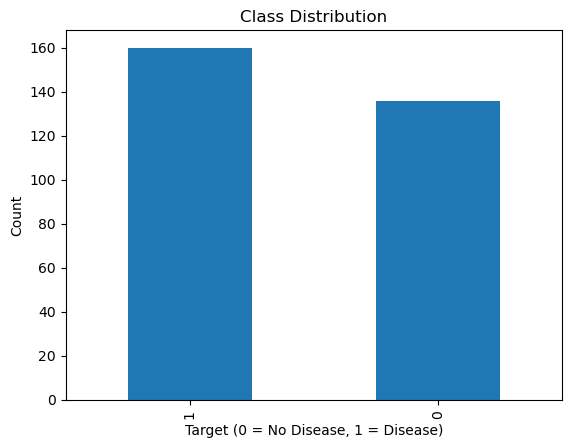

In [13]:
df['target'].value_counts().plot(kind='bar')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

#### Class distribution: After cleaning, the dataset contains 296 patients: 160 with heart disease (54%) and 136 without (46%). The classes are reasonably balanced, so no resampling or class-weighting techniques are needed before training.


### Prepare a stratified 70/30 train/test split and normalize numerical features and Select at least six features, such as age, cholesterol, blood pressure, maximum heart rate, ST depression, and number of vessels

#### Now to divide the dataset in 70/30 maintaining the 54/46 I´m going to use the following function:

In [14]:
np.random.seed(42)

def split_class(df_class, train_frac=0.7):
    n = len(df_class)
    shuffled_idx = np.random.permutation(n)   
    cutoff = int(n * train_frac)
    train_idx = shuffled_idx[:cutoff]
    test_idx = shuffled_idx[cutoff:]
    return df_class.iloc[train_idx], df_class.iloc[test_idx]

df_0 = df[df['target'] == 0]
df_1 = df[df['target'] == 1]

train_0, test_0 = split_class(df_0)
train_1, test_1 = split_class(df_1)

train_df = pd.concat([train_0, train_1])
test_df = pd.concat([test_0, test_1])

print(train_df.shape, test_df.shape)
print(train_df['target'].value_counts(normalize=True))
print(test_df['target'].value_counts(normalize=True))


(207, 14) (89, 14)
1    0.541063
0    0.458937
Name: target, dtype: float64
1    0.539326
0    0.460674
Name: target, dtype: float64
